<a href="https://colab.research.google.com/github/subhamsam007/Machine-Learning/blob/main/insurance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine-Learning-Part-1


# EDA



**Step 1: Importing Required Libraries**

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

***Step 2: Reading Dataset***



In [2]:
df= pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


***Step 3: Analyzing the Data***

In [3]:
df.shape

(1338, 7)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


In [6]:
df.columns.tolist()


['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

***Step 4 : Checking Missing Values***




In [7]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


***Step 5 : Checking for the duplicate values***

In [8]:
df.duplicated().sum()

np.int64(1)

In [9]:
df[df.duplicated()]
# Show the actual duplicate row(s)

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [10]:
df[df.duplicated(keep=False)]

# Show all copies of the duplicate row(s), including the first occurrence

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


**Depending on the number of variables under consideration, data analysis can be categorized into three main types: Univariate, Bivariate and Multivariate.**

step 6 - normal distribution ,skieed distribution

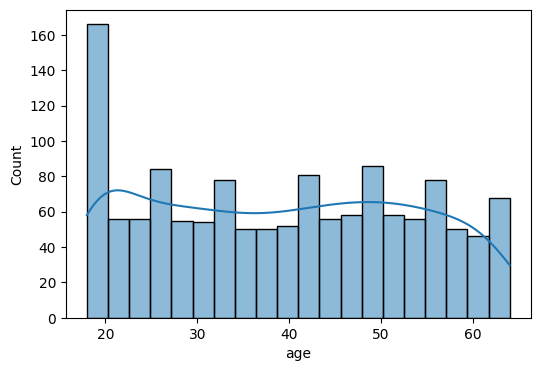

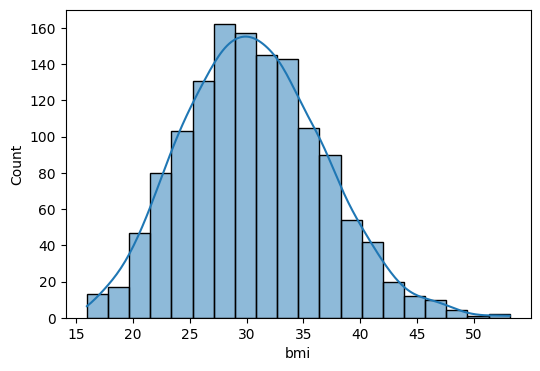

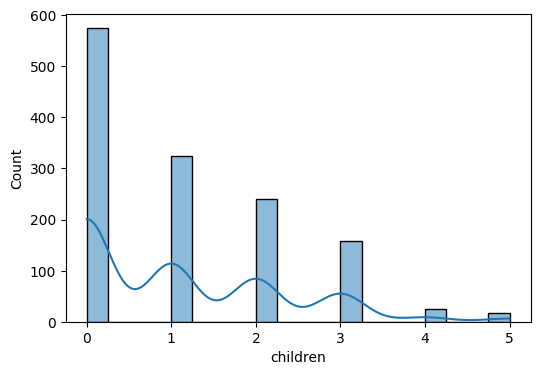

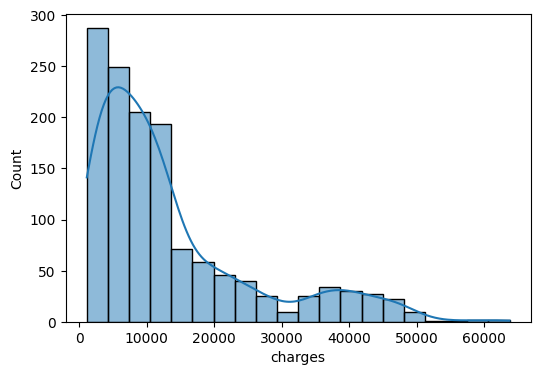

In [11]:
numeric_columns = ['age', 'bmi', 'children','charges']
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde = True,bins = 20)

<Axes: xlabel='sex', ylabel='count'>

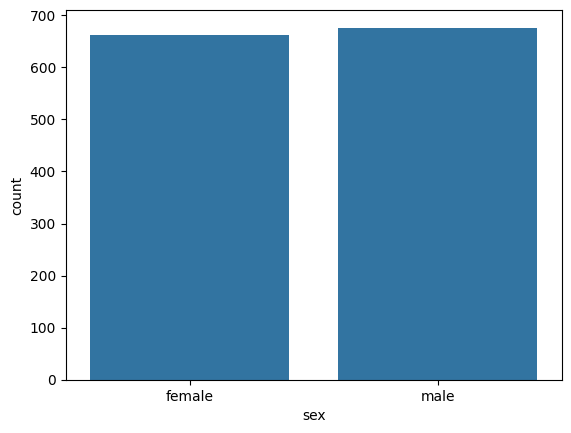

In [12]:
sns.countplot(x=df['sex'])

<Axes: xlabel='smoker', ylabel='count'>

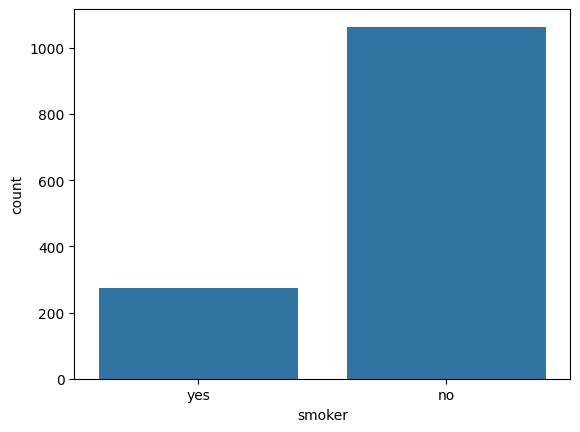

In [13]:
sns.countplot(x=df['smoker'])

<Axes: xlabel='children', ylabel='count'>

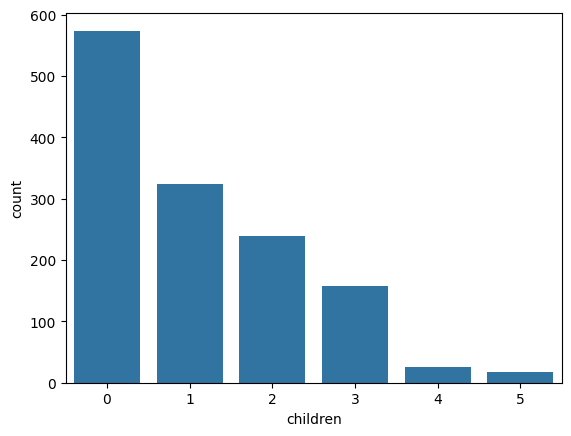

In [14]:
sns.countplot(x=df['children'])

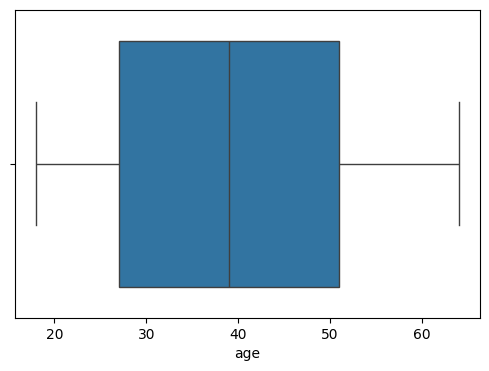

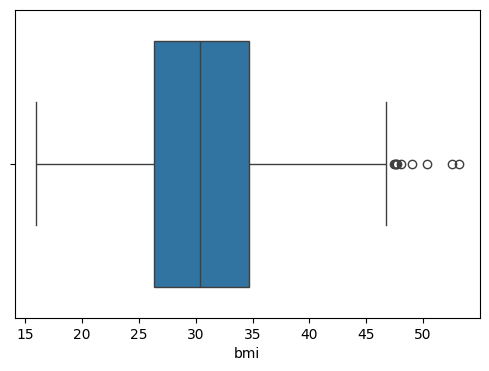

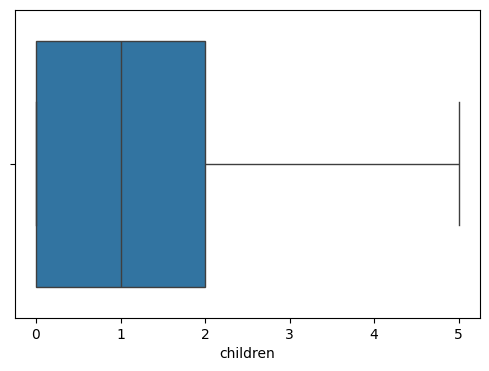

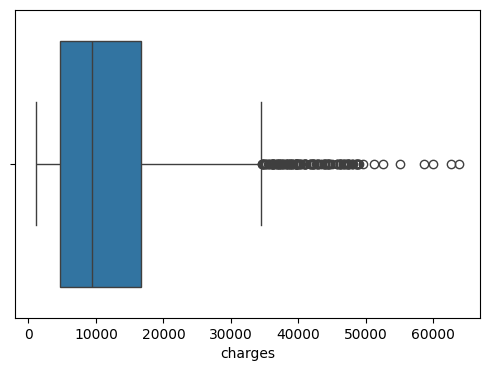

In [15]:
for col in numeric_columns:
  plt.figure(figsize = (6,4))
  sns.boxplot(x =df[col])


Making a heat map undertanding about the correlation about the data which is only about numeric

<Axes: >

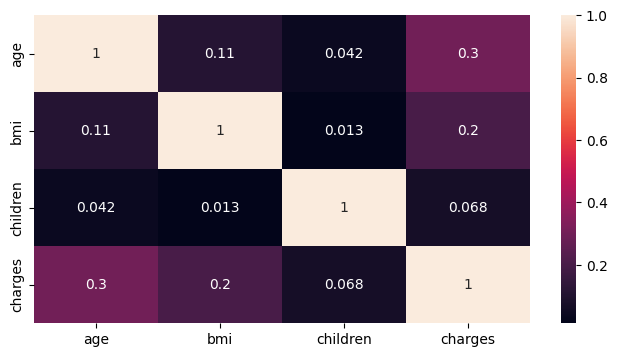

In [16]:
plt.figure(figsize = (8,4))
sns.heatmap(df.corr(numeric_only= True),annot = True)

# Data Cleaning and preprocessing

so now copying the original data into new variable

In [17]:
df_cleaned =df.copy()

In [18]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [19]:
# no droping duplicate
df_cleaned.drop_duplicates(inplace = True)

In [20]:
df_cleaned.shape

(1337, 7)

In [21]:
# now to see the missing value
df_cleaned.isnull().sum()


,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [22]:
df_cleaned.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


so now chnage the object into integers cuz for the mchine learning process
all the value should be in integers

In [23]:
df_cleaned['sex'].value_counts()

,count
sex,
male,675
female,662


so now to do the leavel encoding in the data sets of sex

In [24]:
df_cleaned['sex'] = df_cleaned['sex'].map({'male':0,'female':1})

In [25]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [26]:
# no same thing with smoker
df_cleaned['smoker'].value_counts()
df_cleaned['smoker']= df_cleaned['smoker'].map({'yes':1,'no':0})

In [27]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


now rename of the 2 columns to be more understandable

In [28]:
df_cleaned.rename(columns={
    'sex' :'is_female',
    'smoker': 'is_smoker'},inplace = True)

In [29]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


One-Hot Encoding in region colums

In [30]:
df['region'].value_counts()

,count
region,
southeast,364
southwest,325
northwest,325
northeast,324


** Use pd.get_dummies() to one-hot encode the categorical columns**

In [31]:
df_cleaned = pd.get_dummies(df_cleaned,columns = ['region'])
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,False,True
1,18,0,33.770,1,0,1725.55230,False,False,True,False
2,28,0,33.000,3,0,4449.46200,False,False,True,False
3,33,0,22.705,0,0,21984.47061,False,True,False,False
4,32,0,28.880,0,0,3866.85520,False,True,False,False


now to convert the str value into int


In [32]:
df_cleaned = df_cleaned.astype(int)

In [33]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,0,1
1,18,0,33,1,0,1725,0,0,1,0
2,28,0,33,3,0,4449,0,0,1,0
3,33,0,22,0,0,21984,0,1,0,0
4,32,0,28,0,0,3866,0,1,0,0


# Feature Engineering and Extraction

<Axes: xlabel='bmi', ylabel='Count'>

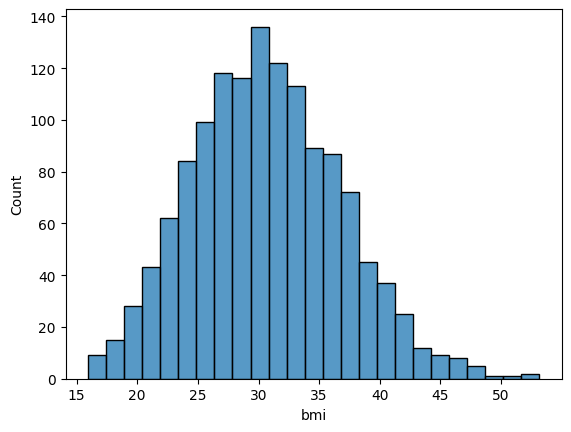

In [34]:
sns.histplot(df['bmi'])

making a new feature from the bmi index

In [35]:
df_cleaned['bmi_category'] = pd.cut(
    df_cleaned['bmi'],
    bins=[0, 18.5, 24.9, 29.9, float('inf')],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese']
)
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,0,1,Overweight
1,18,0,33,1,0,1725,0,0,1,0,Obese
2,28,0,33,3,0,4449,0,0,1,0,Obese
3,33,0,22,0,0,21984,0,1,0,0,Normal
4,32,0,28,0,0,3866,0,1,0,0,Overweight


In [36]:
df_cleaned['bmi_category'].value_counts()

,count
bmi_category,
Obese,706
Overweight,386
Normal,221
Underweight,24


**now One-Hot Encoding in bmi colums**

In [37]:
df_cleaned = pd.get_dummies(df_cleaned,columns = ['bmi_category'],drop_first=True)
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,1,27,0,1,16884,0,0,0,1,False,True,False
1,18,0,33,1,0,1725,0,0,1,0,False,False,True
2,28,0,33,3,0,4449,0,0,1,0,False,False,True
3,33,0,22,0,0,21984,0,1,0,0,True,False,False
4,32,0,28,0,0,3866,0,1,0,0,False,True,False


In [38]:
df_cleaned= df_cleaned.astype(int)

In [39]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,1,27,0,1,16884,0,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,0,1,0,0,0,1
3,33,0,22,0,0,21984,0,1,0,0,1,0,0
4,32,0,28,0,0,3866,0,1,0,0,0,1,0


# features scaling

In [40]:
df_cleaned.columns.to_list()


['age',
 'is_female',
 'bmi',
 'children',
 'is_smoker',
 'charges',
 'region_northeast',
 'region_northwest',
 'region_southeast',
 'region_southwest',
 'bmi_category_Normal',
 'bmi_category_Overweight',
 'bmi_category_Obese']

In [41]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,1,27,0,1,16884,0,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,0,1,0,0,0,1
3,33,0,22,0,0,21984,0,1,0,0,1,0,0
4,32,0,28,0,0,3866,0,1,0,0,0,1,0


now as we can see that all the rows values are 0 and 1 so for that we have to find that wich colums valus are not 0 and 1 so that we can  make model

In [42]:
from sklearn.preprocessing import StandardScaler
cols = ['age','bmi','children']

df_cleaned[cols] = StandardScaler().fit_transform(df_cleaned[cols])

In [43]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,0,1,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,0,1,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,0,1,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,0,1,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,0,10600,0,1,0,0,0,0,1
1334,-1.511647,1,0.135659,-0.909234,0,2205,1,0,0,0,0,0,1
1335,-1.511647,1,0.952670,-0.909234,0,1629,0,0,1,0,0,0,1
1336,-1.297958,1,-0.844753,-0.909234,0,2007,0,0,0,1,0,1,0


**Pearson Correlation Coefficient (PCC)**

In [44]:
from scipy.stats import pearsonr

# ----------------------------------
# Pearson Correlation Calculation
# ----------------------------------

# List of features to check against target
selected_features = [
    'age', 'bmi', 'children', 'is_female', 'is_smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'
]

correlations = {
    feature: pearsonr(df_cleaned[feature], df_cleaned['charges'])[0]
    for feature in selected_features
}
correlation_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Pearson Correlation'])
correlation_df.sort_values(by='Pearson Correlation', ascending=False)

,Feature,Pearson Correlation
4,is_smoker,0.787234
0,age,0.298309
10,bmi_category_Obese,0.200348
1,bmi,0.196236
6,region_southeast,0.073577
2,children,0.067390
5,region_northwest,-0.038695
7,region_southwest,-0.043637
3,is_female,-0.058046
8,bmi_category_Normal,-0.104042


In [45]:
correlation_df

,Feature,Pearson Correlation
0,age,0.298309
1,bmi,0.196236
2,children,0.067390
3,is_female,-0.058046
4,is_smoker,0.787234
5,region_northwest,-0.038695
6,region_southeast,0.073577
7,region_southwest,-0.043637
8,bmi_category_Normal,-0.104042
9,bmi_category_Overweight,-0.120601


# Chi-squared test

**Chi-squared test, or χ² test, helps in determining whether these two variables are associated with each other. mainly on categorical features**

In [46]:
cat_features = [
    'is_female', 'is_smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'
]

In [47]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

df_cleaned['charges_bin'] = pd.qcut(df_cleaned['charges'], q=4, labels=False)
chi2_results = {}

for col in cat_features:
    contingency = pd.crosstab(df_cleaned[col], df_cleaned['charges_bin'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')
chi2_df

,chi2_statistic,p_value,Decision
is_smoker,848.219178,0.0,Reject Null (Keep Feature)
region_southeast,15.998167,0.001135,Reject Null (Keep Feature)
is_female,10.258784,0.01649,Reject Null (Keep Feature)
bmi_category_Obese,8.515711,0.036473,Reject Null (Keep Feature)
region_southwest,5.091893,0.165191,Accept Null (Drop Feature)
bmi_category_Overweight,4.25149,0.235557,Accept Null (Drop Feature)
bmi_category_Normal,3.708088,0.29476,Accept Null (Drop Feature)
region_northwest,1.13424,0.768815,Accept Null (Drop Feature)


Bar plot: Each bar shows the p‑value for a categorical feature.

Red dashed line: Marks the significance threshold (α = 0.05).

Features with bars below the line are statistically significant (reject null → keep feature).

Features above the line are not significant (accept null → drop feature). **bold text**

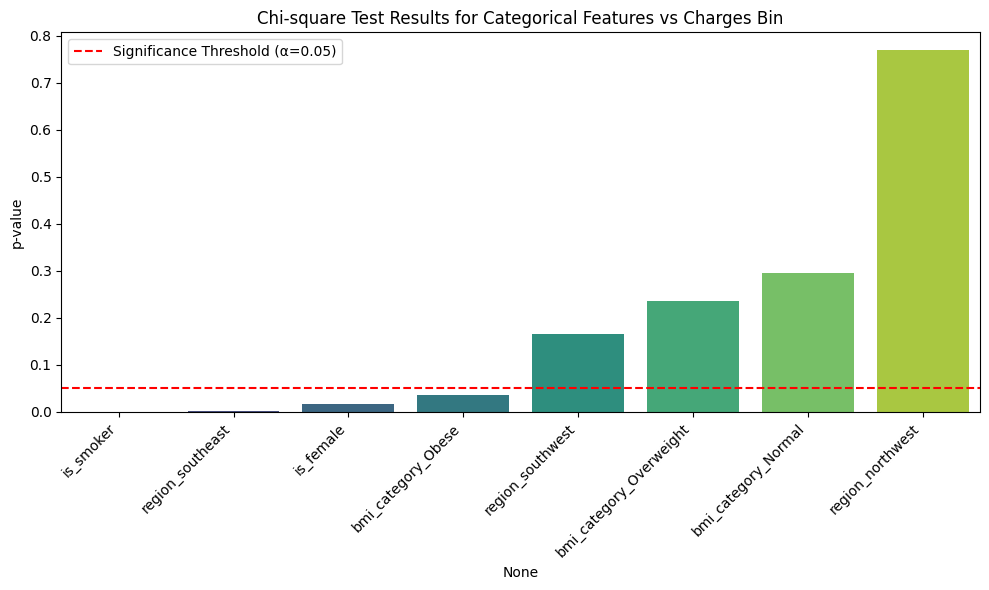

In [48]:
#

plt.figure(figsize=(10,6))

# Plot histogram/bar chart of p-values for each categorical feature
sns.barplot(
    x=chi2_df.index,
    y=chi2_df['p_value'],
    palette="viridis"
)

# Add a horizontal line for alpha = 0.05
plt.axhline(y=0.05, color='red', linestyle='--', label='Significance Threshold (α=0.05)')

# Formatting
plt.xticks(rotation=45, ha='right')
plt.ylabel("p-value")
plt.title("Chi-square Test Results for Categorical Features vs Charges Bin")
plt.legend()
plt.tight_layout()
plt.show()


In [49]:
final_df = df_cleaned[['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges','region_southeast','bmi_category_Obese']]

In [55]:
final_df

,age,is_female,bmi,children,is_smoker,charges,region_southeast,bmi_category_Obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0
1,-1.511647,0,0.462463,-0.079442,0,1725,1,1
2,-0.799350,0,0.462463,1.580143,0,4449,1,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,0,0
...,...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,0,10600,0,1
1334,-1.511647,1,0.135659,-0.909234,0,2205,0,1
1335,-1.511647,1,0.952670,-0.909234,0,1629,1,1
1336,-1.297958,1,-0.844753,-0.909234,0,2007,0,0


# creating model

**Train test split**

In [56]:
from sklearn.model_selection import train_test_split


**x will be the predicting from the parameter
and y will be the predictions**

In [57]:
X = final_df.drop('charges', axis=1)
y = final_df['charges']

**split the traning data and the test data**

In [65]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)


In [66]:
y_test

,charges
900,8688
1064,5708
1256,11436
298,38746
237,4463
...,...
534,13831
542,13887
760,3925
1284,47403


**Creating model of linear regression**

In [63]:
from sklearn.linear_model import LinearRegression

In [64]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()